In [ ]:
import pandas as pd

solar_df = pd.read_csv(
    "/content/solar_forecasting_processed (1).csv"
)

print("Shape:", solar_df.shape)
print("\nColumns:")
print(solar_df.columns.tolist())

print("\nFirst 5 rows:")
display(solar_df.head())

print("\nMissing values:")
print(solar_df.isna().sum().sum())

Shape: (17184, 23)

Columns:
['Timestamp', 'Total_Solar_kWh', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_daylight', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_2', 'rolling_mean_4', 'rolling_mean_48']

First 5 rows:


,Timestamp,Total_Solar_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,hour_sin,...,is_daylight,lag_1,lag_2,lag_4,lag_48,lag_96,lag_336,rolling_mean_2,rolling_mean_4,rolling_mean_48
0,2012-07-08 00:00:00,0.021,0,0,6,8,7,190,1,0.000000,...,0,0.018,0.018,0.025,0.033,0.031,0.015,0.0180,0.01850,22.116854
1,2012-07-08 00:30:00,0.037,0,30,6,8,7,190,1,0.130526,...,0,0.021,0.018,0.013,0.014,0.026,0.024,0.0195,0.01750,22.116604
2,2012-07-08 01:00:00,0.025,1,0,6,8,7,190,1,0.258819,...,0,0.037,0.021,0.018,0.016,0.010,0.049,0.0290,0.02350,22.117083
3,2012-07-08 01:30:00,0.021,1,30,6,8,7,190,1,0.382683,...,0,0.025,0.037,0.018,0.030,0.039,0.027,0.0310,0.02525,22.117271
4,2012-07-08 02:00:00,0.048,2,0,6,8,7,190,1,0.500000,...,0,0.021,0.025,0.021,0.040,0.038,0.038,0.0230,0.02600,22.117083



Missing values:
0


In [ ]:
grid_weather = pd.read_csv(
    "/content/grid_weather_30min.csv"
)

grid_weather["time"] = pd.to_datetime(grid_weather["time"])

print("Shape:", grid_weather.shape)

print("\nColumns:")
print(grid_weather.columns.tolist())

print("\nFirst 5 rows:")
display(grid_weather.head())

print("\nMissing values:")
print(grid_weather.isna().sum())

Shape: (17520, 6)

Columns:
['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'precipitation', 'wind_speed_10m']

First 5 rows:


,time,temperature_2m,relative_humidity_2m,cloud_cover,precipitation,wind_speed_10m
0,2012-07-01 00:00:00,10.010368,79.585284,45.538462,0.0,7.482609
1,2012-07-01 00:30:00,10.010368,79.585284,45.538462,0.0,7.482609
2,2012-07-01 01:00:00,9.968896,79.745819,42.133779,0.0,7.298662
3,2012-07-01 01:30:00,9.968896,79.745819,42.133779,0.0,7.298662
4,2012-07-01 02:00:00,9.181271,82.548495,36.826087,0.0,7.474247



Missing values:
time                    0
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
precipitation           0
wind_speed_10m          0
dtype: int64


In [ ]:
solar_df["Timestamp"] = pd.to_datetime(solar_df["Timestamp"])

print("solar_df Timestamp:", solar_df["Timestamp"].dtype)
print("grid_weather time:", grid_weather["time"].dtype)

solar_df Timestamp: datetime64[ns]
grid_weather time: datetime64[ns]


In [ ]:
solar_weather = solar_df.merge(
    grid_weather,
    left_on="Timestamp",
    right_on="time",
    how="left"
).drop(columns=["time"])

print("Shape:", solar_weather.shape)

print("\nMissing values:")
print(solar_weather.isna().sum())

print("\nFirst 5 rows:")
display(solar_weather.head())

Shape: (17184, 28)

Missing values:
Timestamp               0
Total_Solar_kWh         0
hour                    0
minute                  0
day_of_week             0
day_of_month            0
month                   0
day_of_year             0
is_weekend              0
hour_sin                0
hour_cos                0
day_of_year_sin         0
day_of_year_cos         0
is_daylight             0
lag_1                   0
lag_2                   0
lag_4                   0
lag_48                  0
lag_96                  0
lag_336                 0
rolling_mean_2          0
rolling_mean_4          0
rolling_mean_48         0
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
precipitation           0
wind_speed_10m          0
dtype: int64

First 5 rows:


,Timestamp,Total_Solar_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,hour_sin,...,lag_96,lag_336,rolling_mean_2,rolling_mean_4,rolling_mean_48,temperature_2m,relative_humidity_2m,cloud_cover,precipitation,wind_speed_10m
0,2012-07-08 00:00:00,0.021,0,0,6,8,7,190,1,0.000000,...,0.031,0.015,0.0180,0.01850,22.116854,10.531438,88.254181,36.862876,0.000669,5.452843
1,2012-07-08 00:30:00,0.037,0,30,6,8,7,190,1,0.130526,...,0.026,0.024,0.0195,0.01750,22.116604,10.531438,88.254181,36.862876,0.000669,5.452843
2,2012-07-08 01:00:00,0.025,1,0,6,8,7,190,1,0.258819,...,0.010,0.049,0.0290,0.02350,22.117083,10.416054,88.826087,40.207358,0.035117,6.263880
3,2012-07-08 01:30:00,0.021,1,30,6,8,7,190,1,0.382683,...,0.039,0.027,0.0310,0.02525,22.117271,10.416054,88.826087,40.207358,0.035117,6.263880
4,2012-07-08 02:00:00,0.048,2,0,6,8,7,190,1,0.500000,...,0.038,0.038,0.0230,0.02600,22.117083,9.390301,90.454849,41.471572,0.000000,6.927090


In [ ]:
solar_weather.to_csv(
    "/content/solar_forecasting_weather_processed.csv",
    index=False
)

print("Saved successfully.")
print("Shape:", solar_weather.shape)
print("File: solar_forecasting_weather_processed.csv")

Saved successfully.
Shape: (17184, 28)
File: solar_forecasting_weather_processed.csv


In [ ]:
load_df_processed = pd.read_csv(
    "/content/load_forecasting_processed (1).csv"
)

load_df_processed["Timestamp"] = pd.to_datetime(
    load_df_processed["Timestamp"]
)

print("Shape:", load_df_processed.shape)

print("\nColumns:")
print(load_df_processed.columns.tolist())

print("\nDate range:")
print(
    load_df_processed["Timestamp"].min(),
    "→",
    load_df_processed["Timestamp"].max()
)

print("\nMissing values:", load_df_processed.isna().sum().sum())

Shape: (17183, 26)

Columns:
['Timestamp', 'Total_Load_kWh', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'is_weekend', 'morning_peak', 'evening_peak', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_2', 'rolling_mean_4', 'rolling_mean_48', 'rolling_std_48', 'target']

Date range:
2012-07-08 00:00:00 → 2013-06-30 23:00:00

Missing values: 0


In [ ]:
load_weather_processed = load_df_processed.merge(
    grid_weather,
    left_on="Timestamp",
    right_on="time",
    how="left"
).drop(columns=["time"])

print("Shape:", load_weather_processed.shape)

print("\nMissing values:")
print(load_weather_processed.isna().sum())

print("\nFirst 5 rows:")
display(load_weather_processed.head())

Shape: (17183, 31)

Missing values:
Timestamp               0
Total_Load_kWh          0
hour                    0
minute                  0
day_of_week             0
day_of_month            0
month                   0
day_of_year             0
is_weekend              0
morning_peak            0
evening_peak            0
hour_sin                0
hour_cos                0
day_of_year_sin         0
day_of_year_cos         0
lag_1                   0
lag_2                   0
lag_4                   0
lag_48                  0
lag_96                  0
lag_336                 0
rolling_mean_2          0
rolling_mean_4          0
rolling_mean_48         0
rolling_std_48          0
target                  0
temperature_2m          0
relative_humidity_2m    0
cloud_cover             0
precipitation           0
wind_speed_10m          0
dtype: int64

First 5 rows:


,Timestamp,Total_Load_kWh,hour,minute,day_of_week,day_of_month,month,day_of_year,is_weekend,morning_peak,...,rolling_mean_2,rolling_mean_4,rolling_mean_48,rolling_std_48,target,temperature_2m,relative_humidity_2m,cloud_cover,precipitation,wind_speed_10m
0,2012-07-08 00:00:00,178.265,0,0,6,8,7,190,1,0,...,168.5185,179.65575,155.362979,46.054631,213.914,10.531438,88.254181,36.862876,0.000669,5.452843
1,2012-07-08 00:30:00,213.914,0,30,6,8,7,190,1,0,...,173.4620,176.42000,154.945271,45.746669,184.223,10.531438,88.254181,36.862876,0.000669,5.452843
2,2012-07-08 01:00:00,184.223,1,0,6,8,7,190,1,0,...,196.0895,182.30400,154.926208,45.721369,171.707,10.416054,88.826087,40.207358,0.035117,6.263880
3,2012-07-08 01:30:00,171.707,1,30,6,8,7,190,1,0,...,199.0685,186.26525,154.788979,45.621150,142.249,10.416054,88.826087,40.207358,0.035117,6.263880
4,2012-07-08 02:00:00,142.249,2,0,6,8,7,190,1,0,...,177.9650,187.02725,154.904958,45.657682,118.174,9.390301,90.454849,41.471572,0.000000,6.927090


In [ ]:


load_weather_processed.to_csv(
    "/content/load_forecasting_weather_processed.csv",
    index=False
)

print("Saved successfully.\n")

print("Solar weather dataset:")
print(solar_weather.shape)

print("\nLoad weather dataset:")
print(load_weather_processed.shape)

Saved successfully.

Solar weather dataset:
(17184, 28)

Load weather dataset:
(17183, 31)


In [ ]:
target_col = "Total_Solar_kWh"

exclude_cols = [
    "Timestamp",
    target_col
]

feature_cols_solar_weather = [
    col for col in solar_weather.columns
    if col not in exclude_cols
]

X_solar_weather = solar_weather[feature_cols_solar_weather]
y_solar_weather = solar_weather[target_col]

print("Number of features:", len(feature_cols_solar_weather))

print("\nFeatures:")
print(feature_cols_solar_weather)

print("\nX shape:", X_solar_weather.shape)
print("y shape:", y_solar_weather.shape)

Number of features: 26

Features:
['hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_daylight', 'lag_1', 'lag_2', 'lag_4', 'lag_48', 'lag_96', 'lag_336', 'rolling_mean_2', 'rolling_mean_4', 'rolling_mean_48', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'precipitation', 'wind_speed_10m']

X shape: (17184, 26)
y shape: (17184,)


In [ ]:
n = len(solar_weather)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_sw = X_solar_weather.iloc[:train_end]
y_train_sw = y_solar_weather.iloc[:train_end]

X_val_sw = X_solar_weather.iloc[train_end:val_end]
y_val_sw = y_solar_weather.iloc[train_end:val_end]

X_test_sw = X_solar_weather.iloc[val_end:]
y_test_sw = y_solar_weather.iloc[val_end:]

print("Train:", X_train_sw.shape, y_train_sw.shape)
print("Validation:", X_val_sw.shape, y_val_sw.shape)
print("Test:", X_test_sw.shape, y_test_sw.shape)

print("\nTrain period:")
print(solar_weather["Timestamp"].iloc[0],
      "→",
      solar_weather["Timestamp"].iloc[train_end - 1])

print("\nValidation period:")
print(solar_weather["Timestamp"].iloc[train_end],
      "→",
      solar_weather["Timestamp"].iloc[val_end - 1])

print("\nTest period:")
print(solar_weather["Timestamp"].iloc[val_end],
      "→",
      solar_weather["Timestamp"].iloc[-1])

Train: (12028, 26) (12028,)
Validation: (2578, 26) (2578,)
Test: (2578, 26) (2578,)

Train period:
2012-07-08 00:00:00 → 2013-03-15 13:30:00

Validation period:
2013-03-15 14:00:00 → 2013-05-08 06:30:00

Test period:
2013-05-08 07:00:00 → 2013-06-30 23:30:00


In [ ]:
from xgboost import XGBRegressor

solar_weather_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

solar_weather_model.fit(
    X_train_sw,
    y_train_sw,
    eval_set=[(X_val_sw, y_val_sw)],
    verbose=False
)

print("Weather-enhanced Solar XGBoost training completed.")

Weather-enhanced Solar XGBoost training completed.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

solar_weather_pred = solar_weather_model.predict(X_test_sw)

mae_sw = mean_absolute_error(y_test_sw, solar_weather_pred)
rmse_sw = np.sqrt(mean_squared_error(y_test_sw, solar_weather_pred))
r2_sw = r2_score(y_test_sw, solar_weather_pred)

print("Weather-Enhanced Solar Model")
print("--------------------------------")
print("MAE :", mae_sw)
print("RMSE:", rmse_sw)
print("R²  :", r2_sw)

Weather-Enhanced Solar Model
--------------------------------
MAE : 1.8430740853565755
RMSE: 4.0124721214180585
R²  : 0.9889466968311681


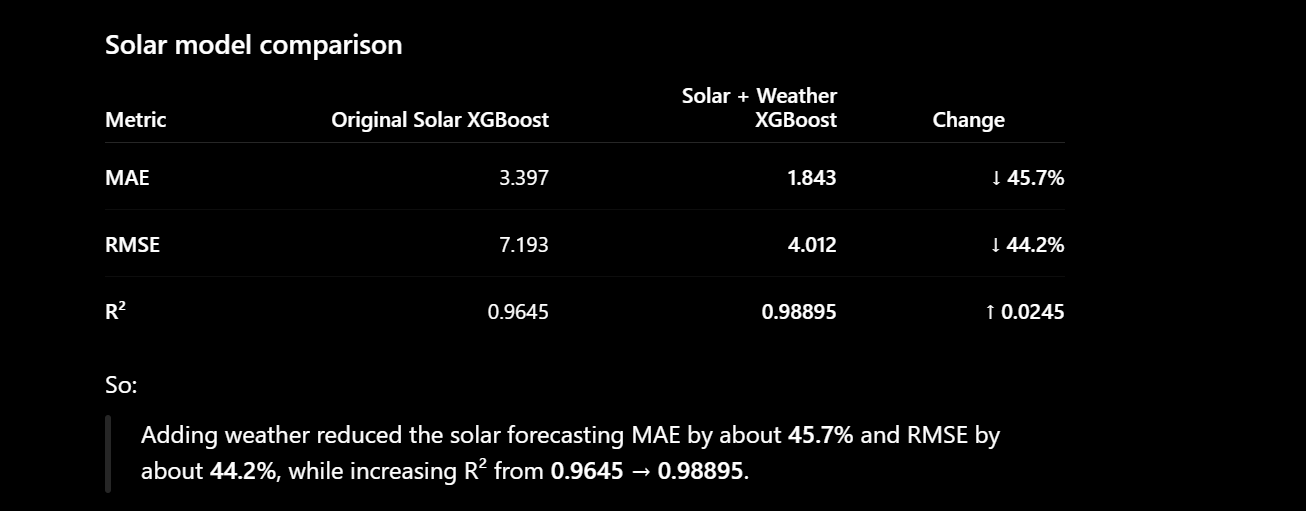

In [ ]:
feature_importance_sw = pd.DataFrame({
    "Feature": feature_cols_solar_weather,
    "Importance": solar_weather_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance_sw)

                 Feature  Importance
12                 lag_1    0.779524
18        rolling_mean_2    0.113994
8               hour_cos    0.022667
7               hour_sin    0.021305
0                   hour    0.020168
13                 lag_2    0.017861
14                 lag_4    0.005029
15                lag_48    0.004378
10       day_of_year_cos    0.002115
23           cloud_cover    0.002057
24         precipitation    0.001341
17               lag_336    0.001174
19        rolling_mean_4    0.001099
22  relative_humidity_2m    0.001029
16                lag_96    0.001014
25        wind_speed_10m    0.000881
20       rolling_mean_48    0.000674
21        temperature_2m    0.000626
5            day_of_year    0.000603
9        day_of_year_sin    0.000546
6             is_weekend    0.000497
3           day_of_month    0.000417
4                  month    0.000351
2            day_of_week    0.000292
1                 minute    0.000201
11           is_daylight    0.000158


In [ ]:
solar_weather_test = pd.DataFrame({
    "Timestamp": solar_weather["Timestamp"].iloc[val_end:].values,
    "Actual_Solar_kWh": y_test_sw.values,
    "Predicted_Solar_kWh": solar_weather_pred
})

solar_weather_test["Error"] = (
    solar_weather_test["Predicted_Solar_kWh"]
    - solar_weather_test["Actual_Solar_kWh"]
)

solar_weather_test["Absolute_Error"] = (
    solar_weather_test["Error"].abs()
)

print("Test predictions shape:", solar_weather_test.shape)

print("\nWorst 10 predictions:")
display(
    solar_weather_test
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

Test predictions shape: (2578, 5)

Worst 10 predictions:


,Timestamp,Actual_Solar_kWh,Predicted_Solar_kWh,Error,Absolute_Error
249,2013-05-13 11:30:00,92.358,126.139946,33.781946,33.781946
2028,2013-06-19 13:00:00,73.198,105.368179,32.170179,32.170179
731,2013-05-23 12:30:00,32.431,60.854877,28.423877,28.423877
1351,2013-06-05 10:30:00,75.796,47.379139,-28.416861,28.416861
2264,2013-06-24 11:00:00,90.918,64.781349,-26.136651,26.136651
253,2013-05-13 13:30:00,44.044,68.727005,24.683005,24.683005
1591,2013-06-10 10:30:00,76.100,100.327347,24.227347,24.227347
1501,2013-06-08 13:30:00,48.737,71.932274,23.195274,23.195274
393,2013-05-16 11:30:00,121.082,143.879807,22.797807,22.797807
680,2013-05-22 11:00:00,47.832,69.822899,21.990899,21.990899


In [ ]:
import joblib

# Save weather-enhanced solar model
joblib.dump(
    solar_weather_model,
    "solar_weather_xgboost_model.pkl"
)

# Save exact feature list used by the model
joblib.dump(
    feature_cols_solar_weather,
    "solar_weather_feature_columns.pkl"
)

# Save test predictions
solar_weather_test.to_csv(
    "solar_weather_predictions.csv",
    index=False
)

print("Solar weather model saved.")
print("Feature columns saved.")
print("Test predictions saved.")

Solar weather model saved.
Feature columns saved.
Test predictions saved.


In [ ]:
# Weather-enhanced load dataset
load_weather = load_weather_processed.copy()

target_col = "Total_Load_kWh"

exclude_cols = [
    "Timestamp",
    target_col
]

feature_cols_load_weather = [
    col for col in load_weather.columns
    if col not in exclude_cols
]

X_load_weather = load_weather[feature_cols_load_weather]
y_load_weather = load_weather[target_col]

print("Dataset shape:", load_weather.shape)
print("Number of features:", len(feature_cols_load_weather))

print("\nWeather features:")
print([
    col for col in feature_cols_load_weather
    if col in [
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "precipitation",
        "wind_speed_10m"
    ]
])

Dataset shape: (17183, 31)
Number of features: 29

Weather features:
['temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'precipitation', 'wind_speed_10m']


In [ ]:
# Chronological 70/15/15 split

n = len(load_weather)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_lw = X_load_weather.iloc[:train_end]
y_train_lw = y_load_weather.iloc[:train_end]

X_val_lw = X_load_weather.iloc[train_end:val_end]
y_val_lw = y_load_weather.iloc[train_end:val_end]

X_test_lw = X_load_weather.iloc[val_end:]
y_test_lw = y_load_weather.iloc[val_end:]

print("Train:", X_train_lw.shape)
print("Validation:", X_val_lw.shape)
print("Test:", X_test_lw.shape)

print("\nDate ranges:")
print("Train:", load_weather["Timestamp"].iloc[0], "→",
      load_weather["Timestamp"].iloc[train_end - 1])

print("Validation:", load_weather["Timestamp"].iloc[train_end], "→",
      load_weather["Timestamp"].iloc[val_end - 1])

print("Test:", load_weather["Timestamp"].iloc[val_end], "→",
      load_weather["Timestamp"].iloc[-1])

Train: (12028, 29)
Validation: (2577, 29)
Test: (2578, 29)

Date ranges:
Train: 2012-07-08 00:00:00 → 2013-03-15 13:30:00
Validation: 2013-03-15 14:00:00 → 2013-05-08 06:00:00
Test: 2013-05-08 06:30:00 → 2013-06-30 23:00:00


In [ ]:
# Correct target: predict load at t+1

feature_cols_load_weather = [
    col for col in load_weather.columns
    if col not in ["Timestamp", "target"]
]

X_load_weather = load_weather[feature_cols_load_weather]
y_load_weather = load_weather["target"]

# Recreate chronological splits
n = len(load_weather)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_lw = X_load_weather.iloc[:train_end]
y_train_lw = y_load_weather.iloc[:train_end]

X_val_lw = X_load_weather.iloc[train_end:val_end]
y_val_lw = y_load_weather.iloc[train_end:val_end]

X_test_lw = X_load_weather.iloc[val_end:]
y_test_lw = y_load_weather.iloc[val_end:]

print("Training:", X_train_lw.shape)
print("Validation:", X_val_lw.shape)
print("Testing:", X_test_lw.shape)

print("\nTarget leakage check:")
print("target" in X_load_weather.columns)

print("\nPrediction objective: Load(t) → Load(t+1)")

Training: (12028, 29)
Validation: (2577, 29)
Testing: (2578, 29)

Target leakage check:
False

Prediction objective: Load(t) → Load(t+1)


In [ ]:
from xgboost import XGBRegressor

load_weather_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

load_weather_model.fit(
    X_train_lw,
    y_train_lw,
    eval_set=[(X_val_lw, y_val_lw)],
    verbose=False
)

print("Weather-enhanced load XGBoost model trained successfully.")

Weather-enhanced load XGBoost model trained successfully.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Test predictions
load_weather_pred = load_weather_model.predict(X_test_lw)

# Evaluation
mae_lw = mean_absolute_error(y_test_lw, load_weather_pred)
rmse_lw = np.sqrt(mean_squared_error(y_test_lw, load_weather_pred))
r2_lw = r2_score(y_test_lw, load_weather_pred)

print("Weather-Enhanced Load Model — Test Results")
print("--------------------------------------------")
print(f"MAE  : {mae_lw:.4f}")
print(f"RMSE : {rmse_lw:.4f}")
print(f"R²   : {r2_lw:.4f}")

print("\nBaseline Load Model")
print("-------------------")
print("MAE  : 7.5718")
print("RMSE : 9.9708")
print("R²   : 0.9463")

Weather-Enhanced Load Model — Test Results
--------------------------------------------
MAE  : 5.7719
RMSE : 7.5109
R²   : 0.9695

Baseline Load Model
-------------------
MAE  : 7.5718
RMSE : 9.9708
R²   : 0.9463


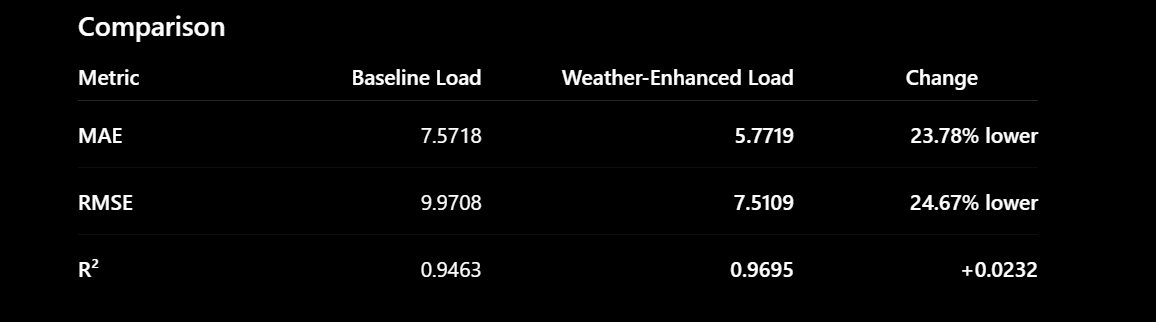

In [ ]:
load_weather_importance = pd.DataFrame({
    "Feature": feature_cols_load_weather,
    "Importance": load_weather_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print("Top 20 Load Forecasting Features:")
display(load_weather_importance.head(20))

Top 20 Load Forecasting Features:


,Feature,Importance
0,Total_Load_kWh,0.496405
14,lag_1,0.233060
19,lag_336,0.035341
10,hour_sin,0.033724
1,hour,0.030434
17,lag_48,0.021764
13,day_of_year_cos,0.021485
11,hour_cos,0.020841
20,rolling_mean_2,0.012316
24,temperature_2m,0.011499


In [ ]:
import joblib

# Save weather-enhanced load model
joblib.dump(
    load_weather_model,
    "load_weather_xgboost_model.pkl"
)

# Save exact feature list
joblib.dump(
    feature_cols_load_weather,
    "load_weather_feature_columns.pkl"
)

# Save test predictions
load_weather_test = pd.DataFrame({
    "Timestamp": load_weather["Timestamp"].iloc[val_end:].values,
    "Actual_Load_kWh": y_test_lw.values,
    "Predicted_Load_kWh": load_weather_pred
})

load_weather_test["Error"] = (
    load_weather_test["Predicted_Load_kWh"]
    - load_weather_test["Actual_Load_kWh"]
)

load_weather_test["Absolute_Error"] = (
    load_weather_test["Error"].abs()
)

load_weather_test.to_csv(
    "load_weather_predictions.csv",
    index=False
)

print("Weather-enhanced load model saved.")
print("Feature columns saved.")
print("Test predictions saved.")

Weather-enhanced load model saved.
Feature columns saved.
Test predictions saved.


In [ ]:
print("Test predictions shape:", load_weather_test.shape)

print("\nWorst 10 load predictions:")

display(
    load_weather_test
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

Test predictions shape: (2578, 5)

Worst 10 load predictions:


,Timestamp,Actual_Load_kWh,Predicted_Load_kWh,Error,Absolute_Error
226,2013-05-12 23:30:00,161.770,130.799225,-30.970775,30.970775
1559,2013-06-09 18:00:00,162.951,192.837540,29.886540,29.886540
2434,2013-06-27 23:30:00,207.771,179.263458,-28.507542,28.507542
1319,2013-06-04 18:00:00,182.496,210.519608,28.023608,28.023608
2330,2013-06-25 19:30:00,241.656,215.540314,-26.115686,26.115686
2166,2013-06-22 09:30:00,184.261,158.364426,-25.896574,25.896574
2050,2013-06-19 23:30:00,203.822,178.624115,-25.197885,25.197885
274,2013-05-13 23:30:00,167.715,142.738876,-24.976124,24.976124
516,2013-05-19 00:30:00,134.642,159.597855,24.955855,24.955855
1635,2013-06-11 08:00:00,113.150,137.977631,24.827631,24.827631


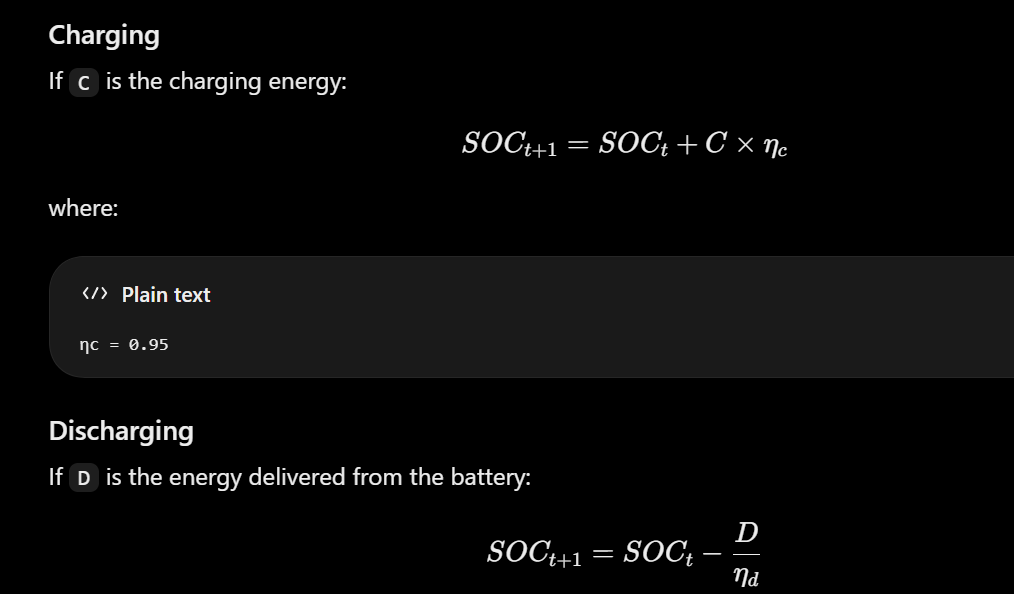